# 11 · Modelo por municipio — GradientBoosting (serializado)

Un GradientBoosting **por municipio** (67 modelos) entrenado sobre el **tablon analitico** (`data/panel_features.parquet`, construido en `08_panel_features`).

- Ficha del modelo: `GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42)`
- Split temporal: train 2016-2021, test 2022-2024 (prediccion recursiva con `lag1` actualizado)
- **Serializacion**: `models/municipio/{cod}.joblib` + `models/metadata.json` (features, ano base, MAPE por municipio) — listos para la API de /simulacion
- Resultados: `results/11_modelo_municipio_metrics.csv`


In [1]:
import polars as pl
import numpy as np
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("data")
RESULTS = Path("results")
MODELS = Path("../models")
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)


In [2]:
import joblib

panel = pl.read_parquet(DATA / "panel_features.parquet")
meta = json.loads((DATA / "panel_metadata.json").read_text())
FEATURES = meta["features"]
TEST_START = meta["test_start"]
TRAIN_DESDE = meta.get("train_desde", 2016)
print("FEATURES:", FEATURES, "| TRAIN_DESDE:", TRAIN_DESDE)
panel.head(5)


FEATURES: ['anio', 'iph_media', 'iph_max', 'ocupacion_media', 'lluvia_anual_mm', 'lag1'] | TRAIN_DESDE: 2016


cod_municipio,nombre_municipio,isla,consumo_hm3,anio,iph_media,iph_max,ocupacion_media,lluvia_anual_mm,lag1
i64,str,str,f64,i64,f64,i64,f64,f64,f64
7001,"""Alaró""","""Mallorca""",0.255,2015,1.0826e6,1388045,0.0,408.1,0.252
7001,"""Alaró""","""Mallorca""",0.278,2016,1.1121e6,1415443,0.0,384.1,0.255
7001,"""Alaró""","""Mallorca""",0.277,2017,1.13149e6,1434094,0.0,496.2,0.278
7001,"""Alaró""","""Mallorca""",0.263,2018,1.1359e6,1414410,0.0,762.0,0.277
7001,"""Alaró""","""Mallorca""",0.279,2019,1.1458e6,1424487,0.0,457.0,0.263


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metricas(test, pred):
    test, pred = np.asarray(test, float), np.asarray(pred, float)
    return dict(
        mae=float(mean_absolute_error(test, pred)),
        mape=float(np.mean(np.abs((test - pred) / test)) * 100),
        rmse=float(mean_squared_error(test, pred) ** 0.5),
        r2=float(r2_score(test, pred)),
    )


In [4]:
from sklearn.ensemble import GradientBoostingRegressor

def predict_recursivo(model, train_df, test_df):
    hist = train_df.sort("anio")
    if hist.height < 2:
        return [float(hist["consumo_hm3"].mean())] * test_df.height
    last = float(hist["consumo_hm3"].to_list()[-1])
    preds = []
    for row in test_df.sort("anio").iter_rows(named=True):
        x = [float(row[f]) for f in FEATURES]
        x[FEATURES.index("lag1")] = last
        p = max(float(model.predict([x])[0]), 0.0)
        preds.append(p)
        last = p
    return preds


In [5]:
# ── Entrenar 67 modelos y evaluar ────────────────────────────────────────────
filas = []
modelos = {}
skipped = []
(MODELS / "municipio").mkdir(exist_ok=True)

for cod_t, g in panel.partition_by("cod_municipio", as_dict=True).items():
    cod = int(cod_t[0])
    train = g.filter((pl.col("anio") >= TRAIN_DESDE) & (pl.col("anio") < TEST_START) & pl.col("lag1").is_not_null())
    test = g.filter(pl.col("anio") >= TEST_START)
    if train.height < 4:
        skipped.append(cod)
        pred = [float(train["consumo_hm3"].mean())] * test.height
    else:
        m = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42)
        m.fit(train.select(FEATURES).to_numpy(), train["consumo_hm3"].to_numpy())
        modelos[cod] = m
        joblib.dump(m, MODELS / "municipio" / f"{cod}.joblib")
        pred = predict_recursivo(m, train, test)
    filas.append({"modelo": "gb_municipio", "cod_municipio": cod,
                  **metricas(test["consumo_hm3"].to_list(), pred)})

print("municipios con train < 4 filas (media historica):", skipped)
res = pd.DataFrame(filas)
res.to_csv(RESULTS / "11_modelo_municipio_metrics.csv", index=False)
print(res[["mae", "mape", "rmse", "r2"]].mean().round(3))


municipios con train < 4 filas (media historica): []
mae      0.121
mape     8.685
rmse     0.131
r2     -21.488
dtype: float64


In [6]:
# ── Serializar metadata (para la API de /simulacion) ─────────────────────────
base_anio = int(panel.filter(pl.col("anio") < TEST_START)["anio"].max())
metadata_modelo = {
    "modelo": "GradientBoostingRegressor",
    "params": {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2, "random_state": 42},
    "features": FEATURES,
    "target": "consumo_hm3",
    "base_anio": base_anio,
    "train_desde": TRAIN_DESDE,
    "test_start": TEST_START,
    "n_modelos": len(modelos),
    "mape_por_municipio": {str(k): round(float(v), 2) for k, v in res.set_index("cod_municipio")["mape"].to_dict().items()},
    "nota": "prediccion recursiva: lag1 se actualiza con la prediccion del anio anterior",
}
(MODELS / "metadata.json").write_text(json.dumps(metadata_modelo, ensure_ascii=False, indent=2))
print("modelos serializados en ../models/municipio/*.joblib + metadata.json")
print("base_anio (ultimo ano de entrenamiento):", base_anio)


modelos serializados en ../models/municipio/*.joblib + metadata.json
base_anio (ultimo ano de entrenamiento): 2021


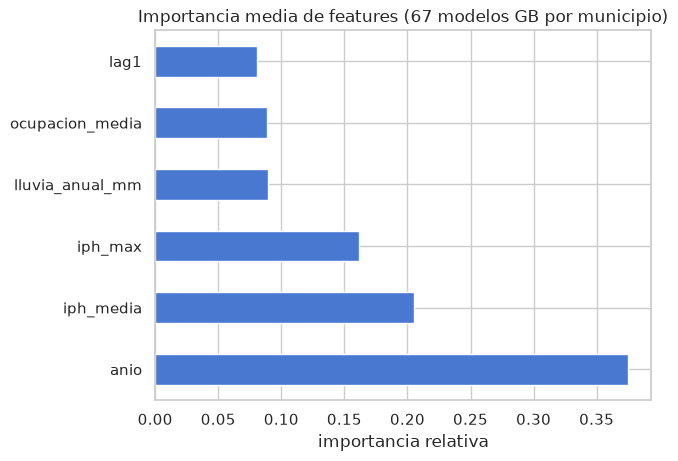

In [7]:
# ── Importancia de variables (media de los 67 modelos) ───────────────────────
imps = pd.DataFrame({str(cod): m.feature_importances_ for cod, m in modelos.items()}, index=FEATURES).T
imps.mean().sort_values(ascending=False).plot(kind="barh")
plt.title("Importancia media de features (67 modelos GB por municipio)")
plt.xlabel("importancia relativa")
plt.show()


In [8]:
# ── Comparacion con los baselines ────────────────────────────────────────────
base = pd.read_csv(RESULTS / "10_baseline_metrics.csv")
for modelo in ["naive", "regla_negocio"]:
    m = base[base["modelo"] == modelo].set_index("cod_municipio")["mape"].sort_index()
    mine = res.set_index("cod_municipio")["mape"].sort_index()
    print(f"gb_municipio mejora a {modelo}:", (mine < m).sum(), "de", len(m), "municipios |",
          f"MAPE {round(mine.mean(),1)} vs {round(m.mean(),1)}")


gb_municipio mejora a naive: 44 de 67 municipios | MAPE 8.7 vs 11.6
gb_municipio mejora a regla_negocio: 38 de 67 municipios | MAPE 8.7 vs 10.2


**Ficha del modelo**

- Algoritmo: `GradientBoostingRegressor` (sklearn), 67 modelos, uno por municipio.
- Parametros: `n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42`.
- Features: ver `08_panel_features` (diccionario). Ventana 2015+; train < 2022.
- Prediccion: recursiva (lag1 = prediccion del ano anterior), sin fuga.
- Artefactos: `models/municipio/{cod}.joblib` + `models/metadata.json`.
- Sin grid search (modelo sencillo y datos escasos — recomendacion del protocolo).
